In [1]:
import pandas as pd
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from utils import readQuotes, parabolic_sar, EMA, ATR

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = readQuotes('..\download_data\T\T_15MIN_history.txt')

In [5]:
df['sar'] = parabolic_sar(df['high'], df['low'])

In [6]:
import datetime
import enum
from typing import List

class PositionDirection(enum.Enum):
    buy = 'buy'
    sell = 'sell'
    cash = 'cash'

    def __str__(self):
        return str(self.value)


class Position:
    def __init__(
        self, direction: PositionDirection,
        open_time: datetime,
        open: float,
        close: float = None,
        close_time: datetime = None
    ):
        self.direction = direction
        self.open_time = open_time
        self.open = open
        self.close = close
        self.close_time = close_time


In [7]:
import matplotlib.pyplot as plt

def calculate_cumulative_pnl(positions):
    # Фильтруем только закрытые позиции (у которых есть close_time и close)
    closed_positions = [p for p in positions if p.close_time is not None and p.close is not None]
    
    # Сортируем по времени закрытия
    closed_positions.sort(key=lambda x: x.close_time)
    
    # Рассчитываем PnL для каждой сделки
    pnl = []
    dates = []
    cumulative = 0
    
    for position in closed_positions:
        if position.direction == PositionDirection.buy:
            trade_pnl = position.close - position.open
        elif position.direction == PositionDirection.sell:
            trade_pnl = position.open - position.close
        else:  # cash
            trade_pnl = 0
        
        cumulative += trade_pnl
        pnl.append(cumulative)
        dates.append(position.close_time)
    
    return dates, pnl

def plot_cumulative_pnl(dates, pnl):
    plt.figure(figsize=(12, 6))
    plt.plot(dates, pnl, marker='o', linestyle='-')
    plt.title('Кумулятивный PnL сделок')
    plt.xlabel('Дата закрытия')
    plt.ylabel('Кумулятивный PnL')
    plt.grid(True)
    plt.axhline(y=0, color='black', linestyle='--')
    plt.tight_layout()
    plt.show()

In [8]:
import pickle
from tqdm import tqdm
from typing import Dict, List
import pandas as pd


def save_progress(data: Dict, filename: str = 'progress.pkl'):
    """Сохраняет текущий прогресс в pickle файл"""
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

def load_progress(filename: str = 'progress.pkl') -> Dict:
    """Загружает прогресс из pickle файла"""
    try:
        with open(filename, 'rb') as f:
            return pickle.load(f)
    except FileNotFoundError:
        return {}

def should_open_buy_position(df: pd.DataFrame, i: int) -> bool:
    """Определяет условия для открытия длинной позиции"""
    return (
        df.iloc[i-2].sar > df.iloc[i-2].high and 
        df.iloc[i-2].sar > df.iloc[i-2].ema and 
        df.iloc[i-1].sar < df.iloc[i-1].low and 
        df.iloc[i-1].sar > df.iloc[i-1].ema and 
        df.iloc[i].open > df.iloc[i-1].sar and 
        df.iloc[i].open > df.iloc[i].ema
    )

def should_open_sell_position(df: pd.DataFrame, i: int) -> bool:
    """Определяет условия для открытия короткой позиции"""
    return (
        df.iloc[i-2].sar < df.iloc[i-2].low and
        df.iloc[i-2].sar < df.iloc[i-2].ema and
        df.iloc[i-1].sar > df.iloc[i-1].high and 
        df.iloc[i-1].sar < df.iloc[i-1].ema and
        df.iloc[i].open < df.iloc[i-1].sar and 
        df.iloc[i].open < df.iloc[i].ema
    )

def should_close_buy_position(position: Position, df: pd.DataFrame, i: int, 
                            coef_prof: float, coef_loss: float) -> bool:
    """Определяет условия для закрытия длинной позиции"""
    return (position.open + coef_prof * df.iloc[i].atr < df.iloc[i].high or
            position.open - coef_loss * df.iloc[i].atr > df.iloc[i].low)

def should_close_sell_position(position: Position, df: pd.DataFrame, i: int,
                             coef_prof: float, coef_loss: float) -> bool:
    """Определяет условия для закрытия короткой позиции"""
    return (position.open - coef_prof * df.iloc[i].atr > df.iloc[i].low or
            position.open + coef_loss * df.iloc[i].atr < df.iloc[i].high)

def process_positions(df: pd.DataFrame, coef_prof: float, coef_loss: float) -> List[Position]:
    """Обрабатывает все позиции для текущих параметров"""
    cur_direction = PositionDirection.cash
    list_positions = []
    cur_position = None

    for i in range(2, df.shape[0]):
        if cur_direction == PositionDirection.cash:
            if should_open_buy_position(df, i):
                cur_direction = PositionDirection.buy
                cur_position = Position(
                    direction=PositionDirection.buy,
                    open=df.iloc[i].open,
                    open_time=df.iloc[i].name
                )
            elif should_open_sell_position(df, i):
                cur_direction = PositionDirection.sell
                cur_position = Position(
                    direction=PositionDirection.sell,
                    open=df.iloc[i].open,
                    open_time=df.iloc[i].name
                )
        else:
            if (cur_position.direction == PositionDirection.buy and 
                should_close_buy_position(cur_position, df, i, coef_prof, coef_loss)):
                
                if cur_position.open + coef_prof * df.iloc[i].atr < df.iloc[i].high:
                    cur_position.close = cur_position.open + coef_prof * df.iloc[i].atr
                else:
                    cur_position.close = cur_position.open - coef_loss * df.iloc[i].atr
                
                cur_position.close_time = df.iloc[i].name
                list_positions.append(cur_position)
                cur_position = None
                cur_direction = PositionDirection.cash
            
            elif (cur_position.direction == PositionDirection.sell and 
                  should_close_sell_position(cur_position, df, i, coef_prof, coef_loss)):
                
                if cur_position.open - coef_prof * df.iloc[i].atr > df.iloc[i].low:
                    cur_position.close = cur_position.open - coef_prof * df.iloc[i].atr
                else:
                    cur_position.close = cur_position.open + coef_loss * df.iloc[i].atr
                
                cur_position.close_time = df.iloc[i].name
                list_positions.append(cur_position)
                cur_position = None
                cur_direction = PositionDirection.cash

    return list_positions

def run_backtest(
    df: pd.DataFrame, 
    ema_range: range = range(25, 31, 5),
    atr_range: range = range(4, 6),
    coef_prof_range: range = range(2, 4),
    coef_loss_range: range = range(2, 4),
    filename: str = 'progress.pkl',
) -> Dict:
    # period_ema=30:period_atr=5:coef_prof=2:coef_loss=2
    """Основная функция для запуска бэктеста"""
    results = load_progress(filename=filename)
    
    for period_ema in tqdm(ema_range, desc="EMA Progress"):
        df['ema'] = EMA(df['close'], period=period_ema)
        
        for period_atr in atr_range:
            df['atr'] = ATR(df, period=period_atr)
            
            for coef_prof in coef_prof_range:
                for coef_loss in coef_loss_range:
                    key = f'{period_ema=}:{period_atr=}:{coef_prof=}:{coef_loss=}'
                    
                    # Пропускаем уже рассчитанные параметры
                    if key in results:
                        continue
                        
                    positions = process_positions(df, coef_prof, coef_loss)
                    results[key] = positions
                    
                    # Сохраняем прогресс после каждой итерации
                    save_progress(results, filename)
    
    return results


In [9]:
results = run_backtest(
    df,
    ema_range=range(25, 100, 5),
    atr_range=range(4, 14),
    coef_prof_range=range(2, 10),
    coef_loss_range=range(1, 10),
    filename='pickle/T_15Min.pickle'
)

EMA Progress:  13%|█▎        | 2/15 [12:13<1:19:28, 366.80s/it]


KeyboardInterrupt: 

In [61]:
results = load_progress('pickle/T_15Min.pickle')

In [62]:
len(results.keys())

1712

In [63]:
list(results.keys())[-1]

'period_ema=35:period_atr=7:coef_prof=8:coef_loss=2'

In [64]:
def best_model(results: Dict):
    best = (0, 0)
    for k, v in results.items():
        d, pnl = calculate_cumulative_pnl(v)
        if len(pnl) > 0 and pnl[-1] > best[1]:
            best = (k, pnl[-1])
    return best

In [65]:
b = best_model(results)

In [66]:
b

('period_ema=35:period_atr=6:coef_prof=3:coef_loss=8', 1634.3547024782574)

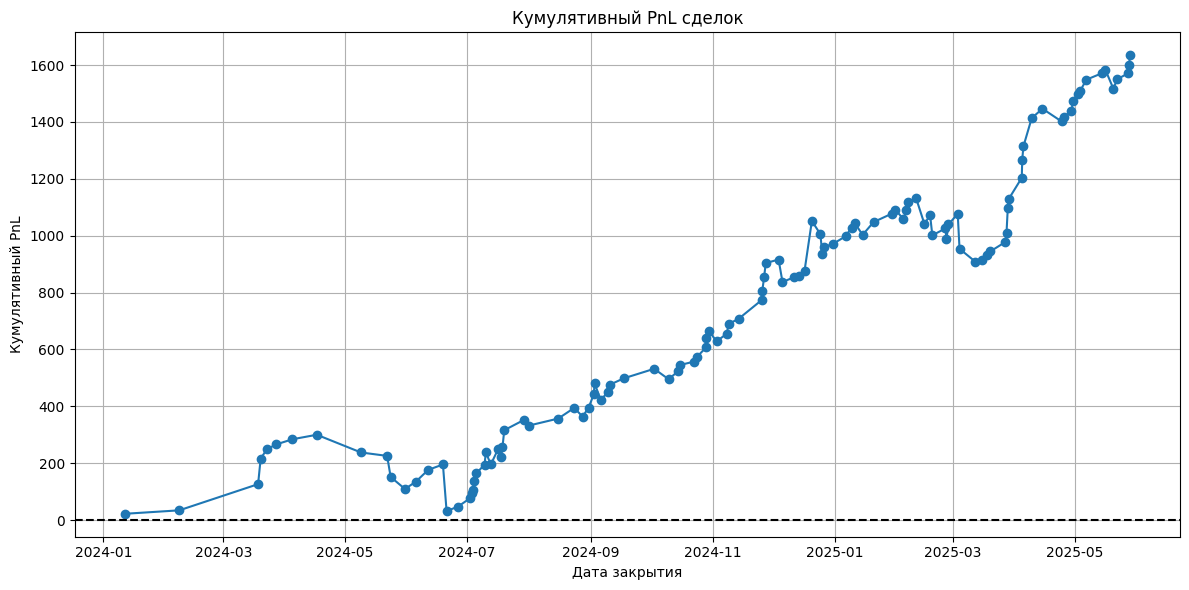

In [70]:
d, pnl = calculate_cumulative_pnl(results[b[0]])
plot_cumulative_pnl(d, pnl)

In [71]:
pl = 0
ll = 0
for i in results[b[0]]:
    if i.direction == PositionDirection.buy and ((i.close - i.open) > 0):
        pl += 1
    elif i.direction == PositionDirection.sell and ((i.open - i.close) > 0):
        pl += 1
    else:
        ll += 1
    
print(f'Удача {pl}')
print(f'Не удача {ll}')
print(f'Winrate {pl/(pl+ll)}')

Удача 90
Не удача 24
Winrate 0.7894736842105263
